In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import glob
import os
import numpy as np
import itertools
import ast
import datetime
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import iris

import iris.quickplot as qplt
import iris.plot as iplt
degree_sign= u'\N{DEGREE SIGN}'
import cmocean
import xarray as xr

def format_x_and_y_ticks(ax: plt.axes, xlocs: list, ylocs: list):
    """Format geoaxes ticks.

    Args:
        ax (plt.axes): axes
        xlocs (list): x locations
        ylocs (list): y locations

    Returns:
        ax: axes
    """

    # Make nicely formatted x- and y-ticks
    xlabels = []
    for j in range(len(xlocs)):
        if xlocs[j] > 0 :
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}E")
        elif xlocs[j] == 0:
            xlabels.append(f"{abs(xlocs[j]):.0f}{degree_sign}")
        else:
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}W")
            
    ax.set_xticks(xlocs)
    ax.set_xticklabels(xlabels)

    ylabels = []
    for j in range(len(ylocs)):
        if ylocs[j] < 0 :
            ylabels.append(f"{abs(ylocs[j]):.1f}{degree_sign}S")
        elif ylocs[j] == 0:
            ylabels.append(f"{abs(ylocs[j]):.0f}{degree_sign}")
        else:
            ylabels.append(f"{ylocs[j]:.1f}{degree_sign}N")
    ax.set_yticks(ylocs)
    ax.set_yticklabels(ylabels)
    ax.grid(linewidth=0.3)
    ax.set_xlabel("")
    ax.set_ylabel("")

    return ax

def circ_mean(h):
    return (np.arctan2(np.sin(2*np.pi*h/24).mean(),np.cos(2*np.pi*h/24).mean()) * 24/(2*np.pi)) % 24

In [144]:
models = ["n1280_CoMA9", "n1280_GAL9_v2", "n2560_CoMA9_hier_v2", "n2560_RAL3p3_tuned"]

In [145]:
def load_mcs(model_id):
    files = glob.glob(f"/gws/ssde/j25a/ncas_climate/vol1/users/ekarl20/data/hackathon_monsoon_data/{model_id}/*.csv")
    
    dfs = []
    
    for file in files:
        dfs.append(pd.read_csv(file))
    
    df = pd.concat(dfs)
    df["timestamp"] = pd.to_datetime(df.timestamp)
    df["model_id"] = model_id

    return df

dfs = []

for model_id in models:
    dfs.append(load_mcs(model_id))

df = pd.concat(dfs)

In [154]:
regions = { "West Africa": {"lat_min": 0, "lat_max": 25, "lon_min": -25, "lon_max": 20}, 
            "South Asia": {"lat_min": 0, "lat_max": 35, "lon_min": 50, "lon_max": 110},
            "East Asia": {"lat_min": 15, "lat_max": 50, "lon_min": 95, "lon_max": 150},
            "North America": {"lat_min": 0, "lat_max": 35, "lon_min": -120, "lon_max": -60},
            "Southern Africa": {"lat_min": -35, "lat_max": -5, "lon_min": 5, "lon_max": 50},
            "Maritime Continent": {"lat_min": -30, "lat_max": 20, "lon_min": 100, "lon_max": 160},
            "South America": {"lat_min": -35, "lat_max": 10, "lon_min": -90, "lon_max": -30}}
regions_list = ["West Africa", "South Asia", "East Asia", "North America", "Southern Africa", "Maritime Continent", "South Africa"]

In [147]:
for region in regions:
    lat1, lat2, lon1, lon2 = regions[region]["lat_min"], regions[region]["lat_max"], regions[region]["lon_min"],  regions[region]["lon_max"]
    print(lat1, lat2, lon1, lon2)

0 25 -25 20
0 35 50 110
15 50 95 150
0 35 -120 40
-35 -5 5 50
-30 20 100 160
-35 10 -90 -30


In [148]:
df[(df.lon >= -90) & (df.lon <= -30) & (df.lat >= -35) & (df.lat <= 10)].groupby("model_id").size()

model_id
n1280_CoMA9            276992
n1280_GAL9_v2          208563
n2560_CoMA9_hier_v2    268400
n2560_RAL3p3_tuned     344526
dtype: int64

In [149]:
df.timestamp

0        2020-02-01 00:04:00
1        2020-02-01 01:04:00
2        2020-02-01 02:04:00
3        2020-02-01 03:04:00
4        2020-02-01 04:04:00
                 ...        
233338   2021-02-01 00:02:00
233339   2021-02-01 01:02:00
233340   2021-01-31 23:02:00
233341   2021-01-31 23:02:00
233342   2021-01-31 23:02:00
Name: timestamp, Length: 10062541, dtype: datetime64[ns]

In [150]:
df["pr_meanxarea"] = df.pr_mean*df.area

In [151]:
mcs_count = np.zeros((len(models), len(regions), 12))
rainfall = np.zeros((len(models), len(regions), 12))

for mdx, model_id in enumerate(models):
    df_ = df[df.model_id == model_id]
    df_storm = df_.groupby("storm_id").first()
    for rdx, region in enumerate(regions):
        lat1, lat2, lon1, lon2 = regions[region]["lat_min"], regions[region]["lat_max"], regions[region]["lon_min"],  regions[region]["lon_max"]
        # print(lat1, lat2, lon1, lon2)
        df2 = df_storm[(df_storm.lon >= lon1) & (df_storm.lon <= lon2) & (df_storm.lat >= lat1) & (df_storm.lat <= lat2)]
        #print(df_storm)
        # print(region, len(df2))
        mcs_count[mdx, rdx] = df2.groupby(df2.timestamp.dt.month).size().reindex(range(1,13), fill_value=0)
        rainfall[mdx, rdx] = (df2.groupby(df2.timestamp.dt.month).pr_meanxarea.sum()).reindex(range(1,13), fill_value=0)

In [152]:
colour_dict = {"n2560_CoMA9_hier_v2": "royalblue",
               "n2560_RAL3p3_tuned": "forestgreen",
              "n1280_CoMA9": "magenta",
               "n1280_GAL9_v2": "gold"
              }

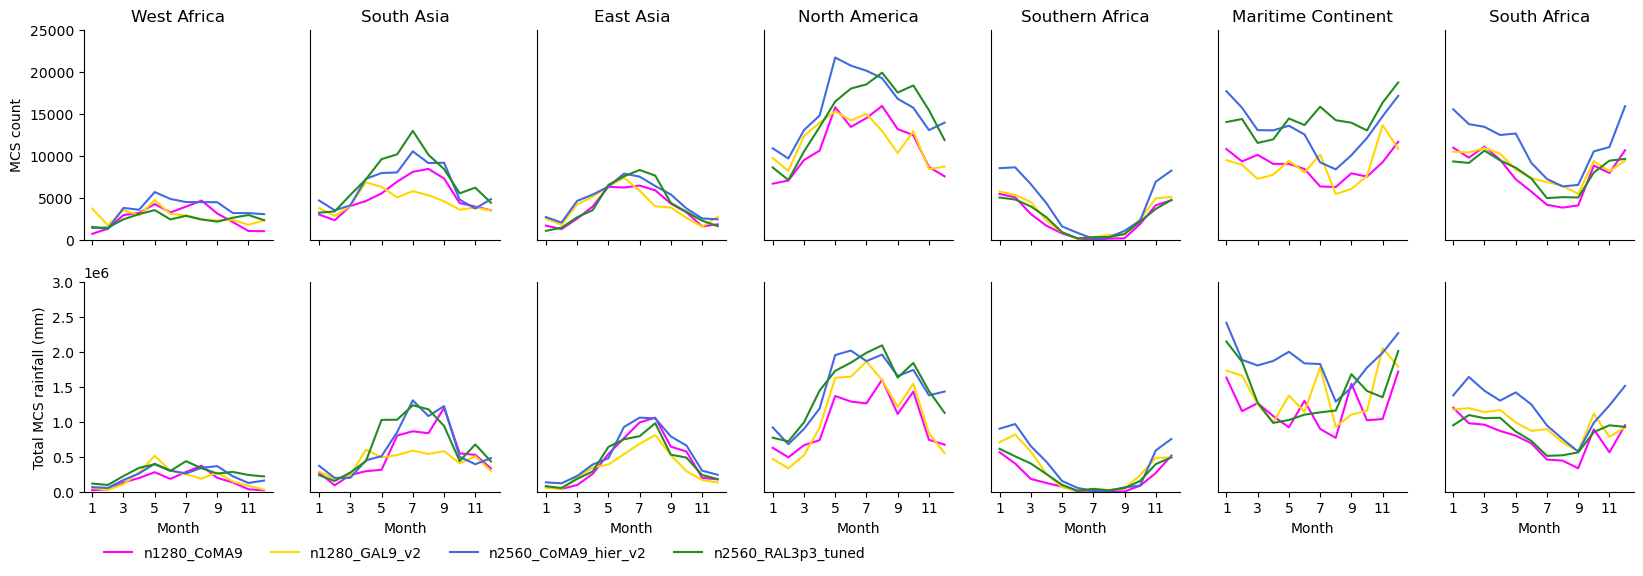

In [153]:
fig, axes = plt.subplots(2,len(regions), figsize=(20,6), sharex=True)

for mdx, model_id in enumerate(models):
    for rdx, region in enumerate(regions):
        axes[0,rdx].plot(range(1,13), mcs_count[mdx,rdx], color=colour_dict[model_id], label=model_id)
        axes[0,rdx].set_title(regions_list[rdx])
        axes[1,rdx].set_xlabel("Month")
        axes[0,rdx].set_xticks(range(1,13, 2))
        axes[0,rdx].set_ylim(0,25000)

        axes[1,rdx].plot(range(1,13), rainfall[mdx,rdx], color=colour_dict[model_id], label=model_id)
        axes[1,rdx].set_ylim(0,3e6)

        if rdx > 0:
            axes[0,rdx].axes.get_yaxis().set_ticks([])
            axes[1,rdx].axes.get_yaxis().set_ticks([])

for ax in axes.ravel():
    ax.spines[['right', 'top']].set_visible(False)
        
axes[0,0].set_ylabel("MCS count")
axes[1,0].set_ylabel("Total MCS rainfall (mm)")

axes[1,0].legend(frameon=False, ncols=4, bbox_to_anchor=(4.2,-0.2))
        
plt.show()

In [27]:
seasons = {"OND": [10,11,12],
          "JJAS": [6,7,8,9],
          "JF": [1,2],
          "MAM": [3,4,5]}

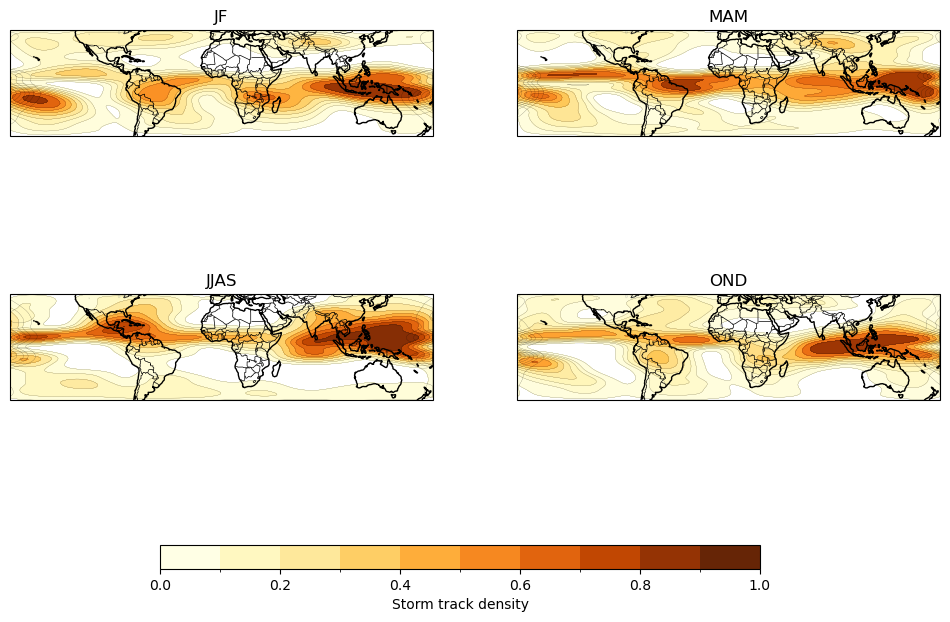

In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

extent = [30.0, 35.5, -3.5, 1.5]
xlocs = [31.5, 33, 34.5]
ylocs = [-3,-1.5,0,1.5]

figsize=(6*2,6*2)

fig, axes = plt.subplots(2,2, figsize=figsize,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0)), facecolor="white")


cmap=plt.get_cmap("twilight")
bounds=np.arange(0,25,1)

norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# df_obs2 = df_obs.groupby("Storm").first()
# df2 = df.groupby("storm_id").first()

season_list = ["JF", "MAM", "JJAS", "OND"]

for i, ax in enumerate(axes.ravel()):
    season = season_list[i]
    ax.coastlines(resolution="110m")
    ax.set_extent([-180,180,-45,45])
    
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidths=0.5)
    ax.add_feature(cfeature.LAKES, edgecolor="black", linewidths=0.5, alpha=0.1)
    
    df2 = df.groupby("storm_id").first()
    df2 = df2[df2.timestamp.dt.month.isin(seasons[season])]
    
    kde1 = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=True, cmap="YlOrBr", alpha=1)
    
    kde = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=False, color="black",
                        linewidths=0.1)
    ax.set_title(season)
    
    
    # sc = ax.scatter(df2.lon, df2.lat, c=df2.eat_hours, cmap=cmap, norm=norm, s=10, transform=ccrs.PlateCarree())
    
    # ax.set_title(extents[storm_type]['label'], color=extents[storm_type]['color'])
    
    ax.set_xlabel("")
    ax.set_ylabel("")


cmap = mpl.cm.YlOrBr
bounds = np.arange(0.,1.01,0.1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

cbar_ax = fig.add_axes([0.25, 0.20, 0.5, 0.02])   # [left, bottom, width, height]

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
cbar.set_label("Storm track density")

plt.subplots_adjust(hspace=-0.6)

plt.show()